In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# In new notebook — load
import pickle
import os

DATA_DIR = r"C:\Users\shaog\OneDrive\Documents\DSE3101\data"
with open(os.path.join(DATA_DIR, "pt_ride_df.pkl"), "rb") as f:
    pt_ride_df = pickle.load(f)

In [4]:
pt_ride_df.head()

,CRD_NUM,JRNY_ID_NUM,BUS_SVC_NUM,ENTRY_DT,ENTRY_TM,EXIT_DT,EXIT_TM,ORIG_LOC_ID_NUM,DEST_LOC_ID_NUM,TRNSPT_MODE_CD,PATRON_CATG_ID_NUM,RIDE_FARE_AMT,RIDE_DIST_KM_CNT,RIDE_MIN_CNT,RIDE_ST_CD,PATRON_CATG_DESC_TXT,TRNSPT_MODE_DESC_TXT,HOUR
0,2200005487496,110732640883,<NA>,2025-02-13,18:38:23,2025-02-13,19:04:14,215,3,2,1,1.66,8.3,25.850,1,Adult,RTS,18
1,0240002779850,110732640058,88,2025-02-13,08:33:24,2025-02-13,08:40:54,3482,3467,1,3,0.00,1.7,7.500,1,Student,BUS,8
2,1700192323745,110732641494,88,2025-02-13,12:36:04,2025-02-13,13:27:24,3562,4646,1,1,1.89,13.2,51.333,1,Adult,BUS,12
3,2200005487496,110732640883,410,2025-02-13,19:26:12,2025-02-13,19:31:41,3438,3492,1,1,0.07,1.0,5.483,1,Adult,BUS,19
4,2230002033461,110732664904,<NA>,2025-02-13,22:57:21,2025-02-13,23:24:02,418,407,2,1,1.89,13.5,26.683,1,Adult,RTS,22


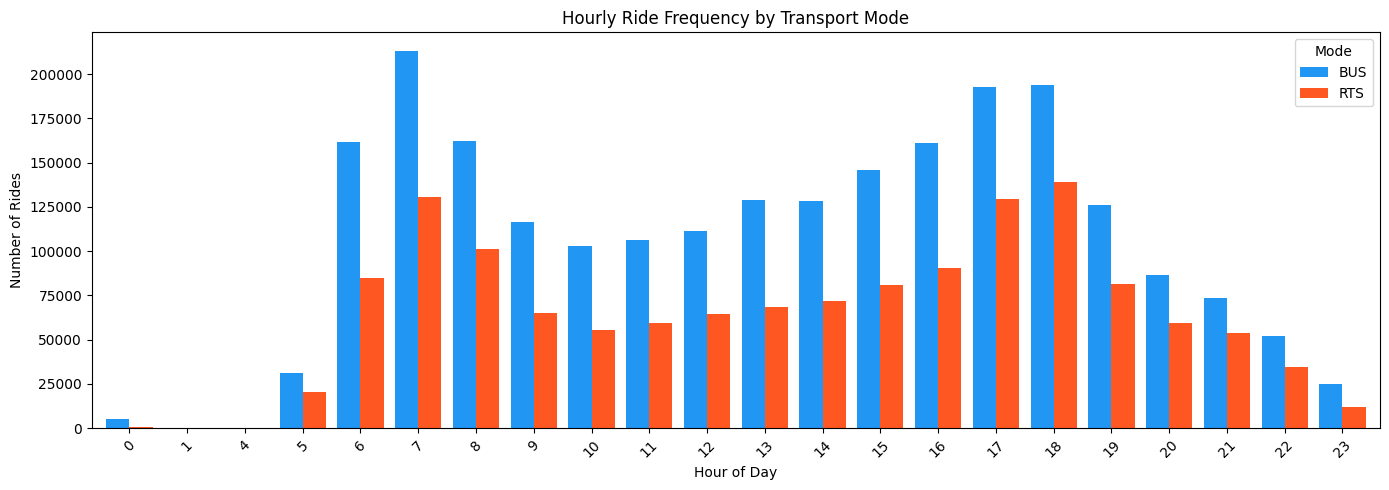

In [6]:
# Extract hour
pt_ride_df['HOUR'] = pt_ride_df['ENTRY_TM'].apply(lambda x: x.hour)
hourly_mode = (
    pt_ride_df.groupby(['HOUR', 'TRNSPT_MODE_DESC_TXT'])
    .size()
    .unstack(fill_value=0)
    .rename_axis(None, axis=1)
)

hourly_mode.plot(kind='bar', figsize=(14, 5), color=['#2196F3', '#FF5722'], width=0.8)
plt.title('Hourly Ride Frequency by Transport Mode')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)
plt.legend(title='Mode')
plt.tight_layout()
plt.show()

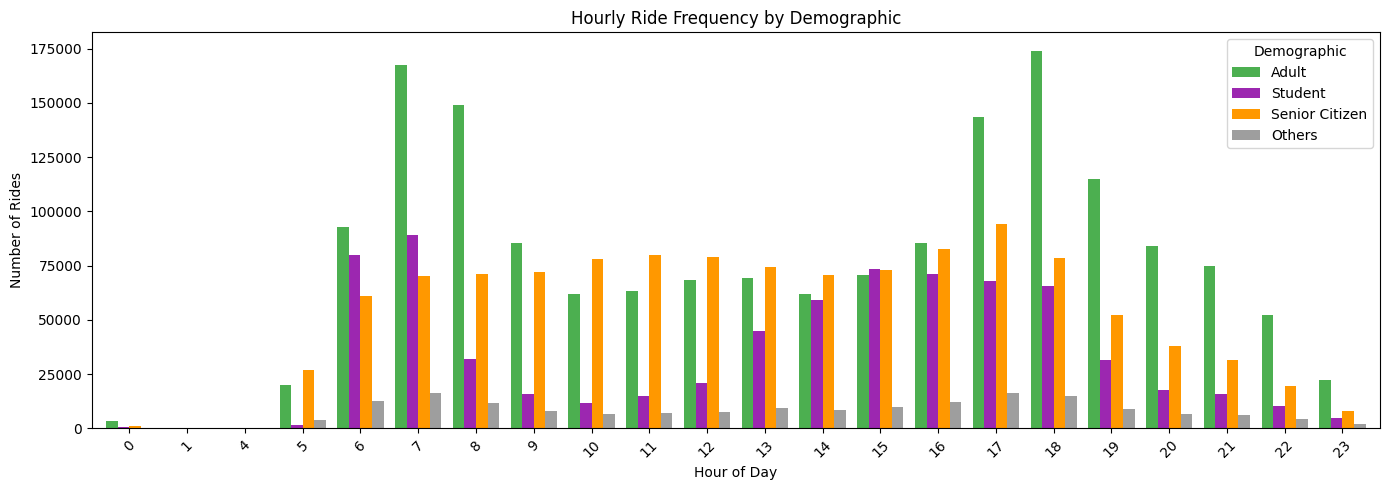

In [7]:
hourly_demo = (
    pt_ride_df.groupby(['HOUR', 'PATRON_CATG_DESC_TXT'])
    .size()
    .unstack(fill_value=0)
    .rename_axis(None, axis=1)
)

demo_grouped = pd.DataFrame({
    'Adult':          hourly_demo['Adult'],
    'Student':        hourly_demo['Student'],
    'Senior Citizen': hourly_demo['Senior Citizen'],
    'Others':         hourly_demo[['Child', 'PWD', 'Staff / Free Fare', 'WTCS']].sum(axis=1)
})

demo_grouped.plot(kind='bar', figsize=(14, 5), color=['#4CAF50', '#9C27B0', '#FF9800', '#9E9E9E'], width=0.8)
plt.title('Hourly Ride Frequency by Demographic')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)
plt.legend(title='Demographic')
plt.tight_layout()
plt.show()